In [1]:
import duckdb
import pandas as pd
import os

# Pfade definieren
data_path = r"C:\Users\Trainee\Desktop\DPP_Projekte\DPP-2026_Julian\data\raw\transfermarkt_data_2026-04-07"
players_file = os.path.join(data_path, "players.csv")
transfers_file = os.path.join(data_path, "transfers.csv")
clubs_file = os.path.join(data_path, "clubs.csv")

# Die korrigierte SQL-Abfrage mit Joins auf die Clubs-Tabelle
query = f"""
SELECT 
    p.player_id,
    p.name,
    p.position,
    p.sub_position,
    (date_part('year', t.transfer_date) - date_part('year', p.date_of_birth)) as age_at_transfer,
    t.transfer_fee as einkaufspreis,
    p.highest_market_value_in_eur as peak_marktwert,
    c_from.domestic_competition_id as origin_league_id,
    t.transfer_date
FROM read_csv_auto('{transfers_file}') t
JOIN read_csv_auto('{players_file}') p ON t.player_id = p.player_id
JOIN read_csv_auto('{clubs_file}') c_to ON t.to_club_id = c_to.club_id
JOIN read_csv_auto('{clubs_file}') c_from ON t.from_club_id = c_from.club_id
WHERE c_to.domestic_competition_id = 'L1'      -- Ziel: Bundesliga
AND c_from.domestic_competition_id != 'L1'     -- Herkunft: Ausland
AND t.transfer_fee >= 100000                   -- Nur Profi-relevante Summen
AND t.transfer_date > '2015-01-01'
"""

df_raw = duckdb.query(query).to_df()

# Dubletten entfernen
df_clean = df_raw.sort_values('transfer_date').drop_duplicates(subset=['player_id'], keep='first').copy()

# ROI Metriken
df_clean['absolute_growth'] = df_clean['peak_marktwert'] - df_clean['einkaufspreis']
df_clean['roi_pct'] = (df_clean['absolute_growth'] / df_clean['einkaufspreis']) * 100
df_clean['roi_score'] = df_clean['roi_pct'] / df_clean['age_at_transfer']

print(f"Datensatz bereit: {len(df_clean)} Transfers identifiziert.")
display(df_clean.head())

Datensatz bereit: 535 Transfers identifiziert.


,player_id,name,position,sub_position,age_at_transfer,einkaufspreis,peak_marktwert,origin_league_id,transfer_date,absolute_growth,roi_pct,roi_score
43,111078,Emil Forsberg,Attack,Left Winger,24,3700000.0,28000000,SE1,2015-01-07,24300000.0,656.756757,27.364865
124,206386,Tin Jedvaj,Defender,Centre-Back,20,7000000.0,9000000,IT1,2015-01-20,2000000.0,28.571429,1.428571
22,73517,Ørjan Nyland,Goalkeeper,Goalkeeper,25,1000000.0,3000000,NO1,2015-07-01,2000000.0,200.000000,8.000000
38,102226,Thorgan Hazard,Midfield,Attacking Midfield,22,8000000.0,45000000,GB1,2015-07-01,37000000.0,462.500000,21.022727
13,55508,Lewis Holtby,Midfield,Central Midfield,25,6500000.0,11000000,GB1,2015-07-01,4500000.0,69.230769,2.769231


In [2]:
# Analyse der Marktwert-Rendite (ROI) von ausländischen Neuzugängen der Bundesliga seit dem 01.01.2015 (Ablöse ≥ 100k €), gewichtet nach dem Transferalter (ROI-Score).

# Hinweis zum ROI-Score: 
# prozentuale Marktwertsteigerung in Prozent / Alter bei Wechsel. Die Analyse misst die maximale Wertschöpfung. Der Zeitraum ist definiert als die Dauer vom Transfer bis zum Erreichen des Peak-Marktwerts. 
# Durch die Division durch das Transfer-Alter wird der Faktor Zeit indirekt berücksichtigt, da jüngere Talente ein längeres Entwicklungsfenster bis zum Peak aufweisen.

# Hinweis zur Methodik: 
# Wir nutzen den 'peak_marktwert' der gesamten Karriere als Proxy für das Scouting-Potenzial einer Region. 
# Dies misst die maximale Qualitätsentwicklung eines Talents nach dem Wechsel nach Deutschland, unabhängig davon, ob dieser Peak noch während der Bundesliga-Zeit oder erst beim nächsten Verein erreicht wurde.

# Next Step: Regionen gruppieren, um Übersicht zu verbessern.

In [3]:
# Aggregation auf Liga-Ebene (ungruppiert)
league_analysis = df_clean.groupby('origin_league_id').agg({
    'player_id': 'count',
    'einkaufspreis': 'mean',
    'peak_marktwert': 'mean',
    'roi_pct': 'mean',
    'roi_score': 'mean'
}).rename(columns={'player_id': 'Anzahl_Transfers'}).sort_values('roi_score', ascending=False)

# Formatierung für bessere Lesbarkeit
league_analysis['Ø_Einkaufspreis'] = league_analysis['einkaufspreis'].map('{:,.0f} €'.format)
league_analysis['Ø_Peak_Marktwert'] = league_analysis['peak_marktwert'].map('{:,.0f} €'.format)
league_analysis['Ø_ROI_%'] = league_analysis['roi_pct'].round(1).astype(str) + '%'
league_analysis['ROI_Score'] = league_analysis['roi_score'].round(2)

# Nur die relevanten Spalten anzeigen
display(league_analysis[['Anzahl_Transfers', 'Ø_Einkaufspreis', 'Ø_Peak_Marktwert', 'Ø_ROI_%', 'ROI_Score']])

,Anzahl_Transfers,Ø_Einkaufspreis,Ø_Peak_Marktwert,Ø_ROI_%,ROI_Score
origin_league_id,,,,,
NO1,7,"1,321,429 €","5,771,429 €",2447.1%,116.36
BE1,40,"6,393,750 €","13,562,500 €",393.5%,17.89
RSK1,4,"525,000 €","2,050,000 €",508.4%,17.74
PO1,15,"10,734,667 €","21,233,333 €",457.1%,16.06
RU1,3,"3,666,667 €","15,833,333 €",405.6%,15.34
JAP1,9,"1,394,444 €","6,766,667 €",362.7%,15.13
BRA1,8,"8,487,500 €","17,062,500 €",278.0%,14.27
FR1,84,"10,643,452 €","24,669,048 €",297.9%,13.71
ES1,24,"11,229,167 €","22,916,667 €",287.9%,12.92


In [4]:
# Erkenntnisse: 
# Norwegen fällt auf als extremer Ausreißer (ROI-Score sechs mal so groß wie Zweitplatzierter Belgien).
# Ligen mit weniger als 10 Transfers werden genauer analysiert.
# Ligen mit extrem wenigen Transfers (n < 6) haben kaum Aussagekraft und werden im nächsten Schritt rausgefiltert.

In [5]:
# 1. Schritt: Ligen mit weniger als 6 Transfers identifizieren und entfernen
league_counts = df_clean['origin_league_id'].value_counts()
leagues_to_keep = league_counts[league_counts >= 6].index

df_filtered = df_clean[df_clean['origin_league_id'].isin(leagues_to_keep)].copy()

# 2. Schritt: Ligen mit 6 bis 9 Transfers für die Ausreißer-Analyse isolieren
outlier_check_leagues = league_counts[(league_counts >= 6) & (league_counts < 10)].index
df_outlier_check = df_filtered[df_filtered['origin_league_id'].isin(outlier_check_leagues)].copy()

# 3. Den Outlier-Check DataFrame zur Ansicht vorbereiten
# Wir sortieren nach Liga und ROI-Score, um die "Spitzen" sofort zu sehen
df_outlier_check_display = df_outlier_check[[
    'origin_league_id', 'name', 'age_at_transfer', 
    'einkaufspreis', 'peak_marktwert', 'roi_score'
]].sort_values(['origin_league_id', 'roi_score'], ascending=[True, False])

print(f"Ligen nach Filterung (n>=6): {len(leagues_to_keep)}")
print(f"Gesamtanzahl Transfers im gefilterten Set: {len(df_filtered)}")
print("\n--- EINZELANSICHT: Ligen mit 6 bis 9 Transfers (Potenzielle Ausreißer) ---")
display(df_outlier_check_display)

Ligen nach Filterung (n>=6): 22
Gesamtanzahl Transfers im gefilterten Set: 521

--- EINZELANSICHT: Ligen mit 6 bis 9 Transfers (Potenzielle Ausreißer) ---


,origin_league_id,name,age_at_transfer,einkaufspreis,peak_marktwert,roi_score
469,ARG1,Piero Hincapié,19,6350000.0,50000000,36.179030
347,ARG1,Santiago Ascacíbar,20,6000000.0,25000000,15.833333
377,ARG1,Nico González,20,11260000.0,40000000,12.761989
328,ARG1,Exequiel Palacios,22,17000000.0,45000000,7.486631
507,ARG1,Julián Malatini,23,2000000.0,3000000,2.173913
424,ARG1,Leonardo Balerdi,20,15500000.0,20000000,1.451613
307,ARG1,Marcelo Saracchi,20,12000000.0,14000000,0.833333
111,ARG1,Lucas Alario,25,19000000.0,20000000,0.210526
255,BRA1,Joelinton,19,2200000.0,42000000,95.215311
268,BRA1,William,22,5000000.0,14000000,8.181818


In [6]:
# Problem: Mittelwert-Orientierung des ROI-Scores zeigt, dass einzelne Ausreißer (z.B. Norwegen/Ryerson, Brasilien/Joelinton) die Platzierung einzelner Ligen extrem beeinflusst.
# Lösung: Ausweichen auf Median statt Mittelwert, um zu zeigen, was ein Bundesliga-Verein im "Normalfall" von einem Transfer aus einer bestimmten Liga erwarten kann.

# Next Step: Median statt Durchschnitt für ROI-Scores


In [7]:
# 1. Sicherstellen, dass nur Ligen mit mindestens 6 Transfers enthalten sind
league_counts = df_clean['origin_league_id'].value_counts()
leagues_to_keep = league_counts[league_counts >= 6].index
df_filtered = df_clean[df_clean['origin_league_id'].isin(leagues_to_keep)].copy()

# 2. Aggregation: Mittelwert UND Median berechnen
league_final = df_filtered.groupby('origin_league_id').agg({
    'player_id': 'count',
    'roi_score': ['mean', 'median'],
    'einkaufspreis': 'median',
    'peak_marktwert': 'median'
})

# Spaltennamen flach machen (Multi-Index auflösen)
league_final.columns = ['Anzahl', 'ROI_Score_Mittelwert', 'ROI_Score_Median', 'Einkauf_Median', 'Peak_MW_Median']

# 3. Nach Median sortieren (da dies unsere "ehrlichere" Metrik ist)
league_final = league_final.sort_values('ROI_Score_Median', ascending=False)

# Formatierung
league_final['ROI_Score_Mittelwert'] = league_final['ROI_Score_Mittelwert'].round(2)
league_final['ROI_Score_Median'] = league_final['ROI_Score_Median'].round(2)
league_final['Einkauf_Median'] = league_final['Einkauf_Median'].map('{:,.0f} €'.format)
league_final['Peak_MW_Median'] = league_final['Peak_MW_Median'].map('{:,.0f} €'.format)

print("LIGA-CHECK: Mittelwert vs. Median (Sortiert nach Median)")
display(league_final)

LIGA-CHECK: Mittelwert vs. Median (Sortiert nach Median)


,Anzahl,ROI_Score_Mittelwert,ROI_Score_Median,Einkauf_Median,Peak_MW_Median
origin_league_id,,,,,
C1,40,9.35,7.96,"3,350,000 €","7,250,000 €"
NL1,48,12.16,7.02,"3,000,000 €","8,000,000 €"
ES1,24,12.92,6.91,"6,750,000 €","18,500,000 €"
BE1,40,17.89,5.95,"3,750,000 €","9,500,000 €"
PO1,15,16.06,5.85,"7,180,000 €","17,000,000 €"
A1,50,12.46,5.32,"3,250,000 €","8,000,000 €"
FR1,84,13.71,4.97,"7,750,000 €","18,000,000 €"
ARG1,8,9.62,4.83,"11,630,000 €","22,500,000 €"
DK1,33,11.09,4.80,"2,500,000 €","4,500,000 €"


In [8]:
# ROI-Score-Mittelwert (Was ist im besten Fall möglich?)
# Zeigt uns das theoretische Potenzial eines Marktes.
# Problem: Einzelne Ausreißer können hier den Wert extrem nach oben oder unten beeinflussen (z.B. Ryerson/Norwegen).

# ROI-Score-Median (Was bekomme ich im Normalfall?)
# Zeigt die Realität für den Normalfall, d.h. eher typische Ergebnisse.
# Erhöht Aussagekraft und Planungssicherheit.

# Key-Takeaway
# Je näher Mittelwert und Median beieinander liegen, desto höher ist die Wahrscheinlichkeit für einen in dieser Liga "durchschnittlichen" Transfer. 

In [9]:
#           Kategorie	                Logik (ROI Median)	    Ligen	                        Kommentar
# Tier 1:   Efficiency Peaks	        Median > 6.0	        C1, NL1, ES1, BE1	            "Sichere Häfen für Wertsteigerung"
# Tier 2:   Solid Development	        Median 4.0 - 6.0	    PO1, A1, FR1, DK1, NO1, PL1	    "Klassische Ausbildungsmärkte"
# Tier 3:   High Capital / Low ROI	    Median 2.0 - 4.0	    GB1, IT1, BRA1, JAP1, SE1	    "Premium-Märkte / Risiko-Invests"
# Tier 4:   Speculative / Low Yield	    Median < 2.0	        TS1, TR1, GR1	                "Vorsicht: Hohe Streuverluste"

In [10]:
# Alle Transfers aus der Schweiz (C1) isolieren
df_schweiz = df_clean[df_clean['origin_league_id'] == 'C1'].copy()

# Sortieren nach ROI-Score, um die Top-Performer oben zu sehen
df_schweiz_detail = df_schweiz[[
    'name', 'position', 'age_at_transfer', 'einkaufspreis', 
    'peak_marktwert', 'roi_score', 'transfer_date'
]].sort_values('roi_score', ascending=False)

# Statistiken für die Schweiz zusammenfassen
print(f"Detail-Analyse: {len(df_schweiz_detail)} Transfers aus der Schweiz (C1)")
display(df_schweiz_detail)

# Kleiner Bonus: Welche Positionen lohnen sich in der Schweiz am meisten?
pos_check_ch = df_schweiz.groupby('position').agg({
    'player_id': 'count',
    'roi_score': 'median'
}).rename(columns={'player_id': 'Anzahl'}).sort_values('roi_score', ascending=False)

print("\n--- ROI nach Positionen innerhalb der Schweiz (Median) ---")
display(pos_check_ch)

Detail-Analyse: 40 Transfers aus der Schweiz (C1)


,name,position,age_at_transfer,einkaufspreis,peak_marktwert,roi_score,transfer_date
108,Nico Elvedi,Defender,19,4000000.0,35000000,40.789474,2015-07-01
107,Ulisses Garcia,Defender,19,600000.0,5000000,38.596491,2015-07-01
113,Albian Ajeti,Attack,19,1000000.0,7000000,31.578947,2016-01-08
391,Matheus Cunha,Attack,19,15000000.0,70000000,19.298246,2018-07-01
168,Rifet Kapic,Midfield,24,150000.0,800000,18.055556,2019-07-01
50,Marius Müller,Goalkeeper,30,350000.0,2000000,15.714286,2023-07-01
336,Betim Fazliji,Midfield,23,450000.0,2000000,14.975845,2022-07-15
354,Matej Maglica,Defender,25,450000.0,2000000,13.777778,2023-07-01
427,Albian Hajdari,Defender,22,5000000.0,20000000,13.636364,2025-08-25
256,Denis Zakaria,Midfield,21,12000000.0,45000000,13.095238,2017-07-01



--- ROI nach Positionen innerhalb der Schweiz (Median) ---


,Anzahl,roi_score
position,,
Midfield,9,11.111111
Defender,19,8.333333
Goalkeeper,2,7.639752
Attack,10,4.721205


In [11]:
# Insights von Schweiz-Analyse
# Median sehr nah an Mittelwert + gleichmäßige Verteilung der Spieler-ROI-Scores = gute Planbarkeit für Transfers, die in dieser Liga typisch sind
# gleichmäßige Staffelung der Spieler mit ähnlichen ROI-Scores (zwischen 10 - 40)
# Keine extremen Ausreißer, d.h. Erfolg wäre hier wahrscheinlich reproduzierbar bei geringem Risiko

In [12]:
# Alle Transfers aus Brasilien (BRA1) isolieren
df_brasilien = df_clean[df_clean['origin_league_id'] == 'BRA1'].copy()

# Sortieren nach ROI-Score, um die Streuung zu sehen
df_brasilien_detail = df_brasilien[[
    'name', 'position', 'age_at_transfer', 'einkaufspreis', 
    'peak_marktwert', 'roi_score', 'transfer_date'
]].sort_values('roi_score', ascending=False)

print(f"Detail-Analyse: {len(df_brasilien_detail)} Transfers aus Brasilien (BRA1)")
display(df_brasilien_detail)

# Statistischer Vergleich: Schweiz vs. Brasilien
comparison = df_clean[df_clean['origin_league_id'].isin(['C1', 'BRA1'])].groupby('origin_league_id').agg({
    'roi_score': ['mean', 'median', 'std', 'min', 'max']
})
print("\n--- Direktvergleich: Stabilität (C1) vs. Volatilität (BRA1) ---")
display(comparison)

Detail-Analyse: 8 Transfers aus Brasilien (BRA1)


,name,position,age_at_transfer,einkaufspreis,peak_marktwert,roi_score,transfer_date
255,Joelinton,Midfield,19,2200000.0,42000000,95.215311,2015-07-01
268,William,Defender,22,5000000.0,14000000,8.181818,2017-07-01
134,Douglas Santos,Defender,22,6500000.0,18000000,8.041958,2016-08-31
243,Walace,Midfield,22,9200000.0,14000000,2.371542,2017-01-30
351,Paulinho,Attack,18,18500000.0,25000000,1.951952,2018-07-16
392,Iago,Defender,22,6500000.0,6500000,0.000000,2019-07-01
352,Luan Cândido,Defender,18,8000000.0,7000000,-0.694444,2019-07-01
1,Kauã Prates,Defender,18,12000000.0,10000000,-0.925926,2026-08-12



--- Direktvergleich: Stabilität (C1) vs. Volatilität (BRA1) ---


roi_score                                          
                       mean    median        std       min        max
origin_league_id                                                     
BRA1              14.267776  2.161747  32.906337 -0.925926  95.215311
C1                 9.346210  7.958554   9.838950 -0.893744  40.789474

In [13]:
# Insight
# Standardabweichung (std) ist bei der Schweiz (9,8) ähnlich groß wie der Mittelwert, d.h. die Ergebnisse haben eine gewisse Berechenbarkeit.
# Für Brasilien ist die Std. (9.84) mehr als doppelt so groß, wie der Mittelwert (14,26), d.h. der Mittelwert ist hier eher wenig aussagekräftig (höhere Volatilität!)

In [14]:
# Vergleichs-Ligen mit solider Datenbasis (n >= 15)
benchmark_leagues = ['C1', 'PL1', 'TS1']

# Statistiken berechnen
benchmark_comparison = df_clean[df_clean['origin_league_id'].isin(benchmark_leagues)].groupby('origin_league_id').agg({
    'player_id': 'count',
    'roi_score': ['mean', 'median', 'std'],
    'einkaufspreis': ['median', 'mean']
})

# Spaltennamen für die Übersichtlichkeit glätten
benchmark_comparison.columns = [
    'Anzahl', 'ROI_Mean', 'ROI_Median', 'Risiko_std', 'Einkauf_Median', 'Einkauf_Mean'
]

print("STRATEGISCHER BENCHMARK: Schweiz vs. Polen vs. Portugal")
display(benchmark_comparison.sort_values('ROI_Median', ascending=False))

STRATEGISCHER BENCHMARK: Schweiz vs. Polen vs. Portugal


,Anzahl,ROI_Mean,ROI_Median,Risiko_std,Einkauf_Median,Einkauf_Mean
origin_league_id,,,,,,
C1,40,9.346210,7.958554,9.838950,3350000.0,5.253750e+06
PL1,9,5.024884,4.761905,5.309797,2000000.0,2.883333e+06
TS1,6,6.141998,1.866987,8.324629,5750000.0,6.500000e+06


In [15]:
# Test-Abfrage ohne Mindest-Ablöse
query_all = f"""
SELECT 
    p.player_id,
    c_from.domestic_competition_id as origin_league_id
FROM read_csv_auto('{transfers_file}') t
JOIN read_csv_auto('{players_file}') p ON t.player_id = p.player_id
JOIN read_csv_auto('{clubs_file}') c_to ON t.to_club_id = c_to.club_id
JOIN read_csv_auto('{clubs_file}') c_from ON t.from_club_id = c_from.club_id
WHERE c_to.domestic_competition_id = 'L1' 
AND c_from.domestic_competition_id != 'L1' 
AND t.transfer_date > '2015-01-01'
"""

df_all = duckdb.query(query_all).to_df()
df_all_clean = df_all.drop_duplicates(subset=['player_id'])

# Vergleich der Fallzahlen
check_counts = df_all_clean['origin_league_id'].value_counts().head(10)
print("Fallzahlen OHNE Preis-Filter (Top 10 Ligen):")
print(check_counts)

# Vergleich mit deinem aktuellen df_clean
print("\nFallzahlen MIT deinem 100k-Filter (Top 10 Ligen):")
print(df_clean['origin_league_id'].value_counts().head(10))

Fallzahlen OHNE Preis-Filter (Top 10 Ligen):
origin_league_id
GB1    139
FR1    106
NL1     99
A1      79
BE1     72
IT1     62
C1      54
ES1     53
DK1     51
TR1     28
Name: count, dtype: int64

Fallzahlen MIT deinem 100k-Filter (Top 10 Ligen):
origin_league_id
FR1    84
GB1    54
A1     50
NL1    48
C1     40
BE1    40
DK1    33
IT1    25
ES1    24
SE1    16
Name: count, dtype: int64


In [16]:
# Mapping-Dictionary für die Ländernamen
league_map = {
    'C1': 'Schweiz', 'NL1': 'Niederlande', 'BE1': 'Belgien', 
    'A1': 'Österreich', 'FR1': 'Frankreich', 'GB1': 'England', 
    'ES1': 'Spanien', 'IT1': 'Italien', 'PO1': 'Portugal',
    'DK1': 'Dänemark', 'PL1': 'Polen', 'SE1': 'Schweden',
    'NO1': 'Norwegen', 'BRA1': 'Brasilien', 'ARG1': 'Argentinien',
    'JAP1': 'Japan', 'MLS1': 'USA', 'SER1': 'Serbien', 
    'TR1': 'Türkei', 'GR1': 'Griechenland', 'TS1': 'Tschechien',
    'RU1': 'Russland', 'RSK1': 'Slowakei', 'KR1': 'Südkorea'
}

# Ländernamen zum DataFrame hinzufügen
plot_data['Land'] = plot_data['origin_league_id'].map(league_map).fillna(plot_data['origin_league_id'])

# --- Grafik 1: ROI-Median pro Land (Balkendiagramm) ---
plt.figure(figsize=(12, 9))
sns.barplot(data=plot_data.sort_values('ROI_Score_Median', ascending=False), 
            x='ROI_Score_Median', y='Land', palette='magma')

plt.title('Effizienz-Ranking: Wo lohnt sich das Investment am meisten?', fontsize=16, fontweight='bold')
plt.xlabel('ROI-Score (Median)', fontsize=12)
plt.ylabel('Herkunftsliga', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- Grafik 2: Risk vs. Reward Matrix (Scatter-Plot) ---
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(data=plot_data, x='Risiko_std', y='ROI_Score_Median', 
                         size='Anzahl', sizes=(100, 1000), alpha=0.7, 
                         hue='ROI_Score_Median', palette='RdYlGn')

# Beschriftung der Punkte mit den Klarnamen
for i in range(plot_data.shape[0]):
    plt.text(plot_data.Risiko_std[i] + 0.8, plot_data.ROI_Score_Median[i], 
             plot_data.Land[i], fontsize=11, fontweight='medium')

plt.title('Die Scouting-Matrix: Stabilität vs. Upside', fontsize=16, fontweight='bold')
plt.xlabel('Risiko (Standardabweichung des ROI)', fontsize=12)
plt.ylabel('Ertrag (Median ROI-Score)', fontsize=12)

# Hilfslinien zur Orientierung (Mediane über alle Ligen)
plt.axhline(plot_data['ROI_Score_Median'].median(), color='black', linestyle=':', alpha=0.4)
plt.axvline(plot_data['Risiko_std'].median(), color='black', linestyle=':', alpha=0.4)

plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.legend(title='Anzahl Transfers', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.xlim(-5, 75)
plt.show()

NameError: name 'plot_data' is not defined

In [ ]:
#Japan fliegt raus als statistischer Ausreißer

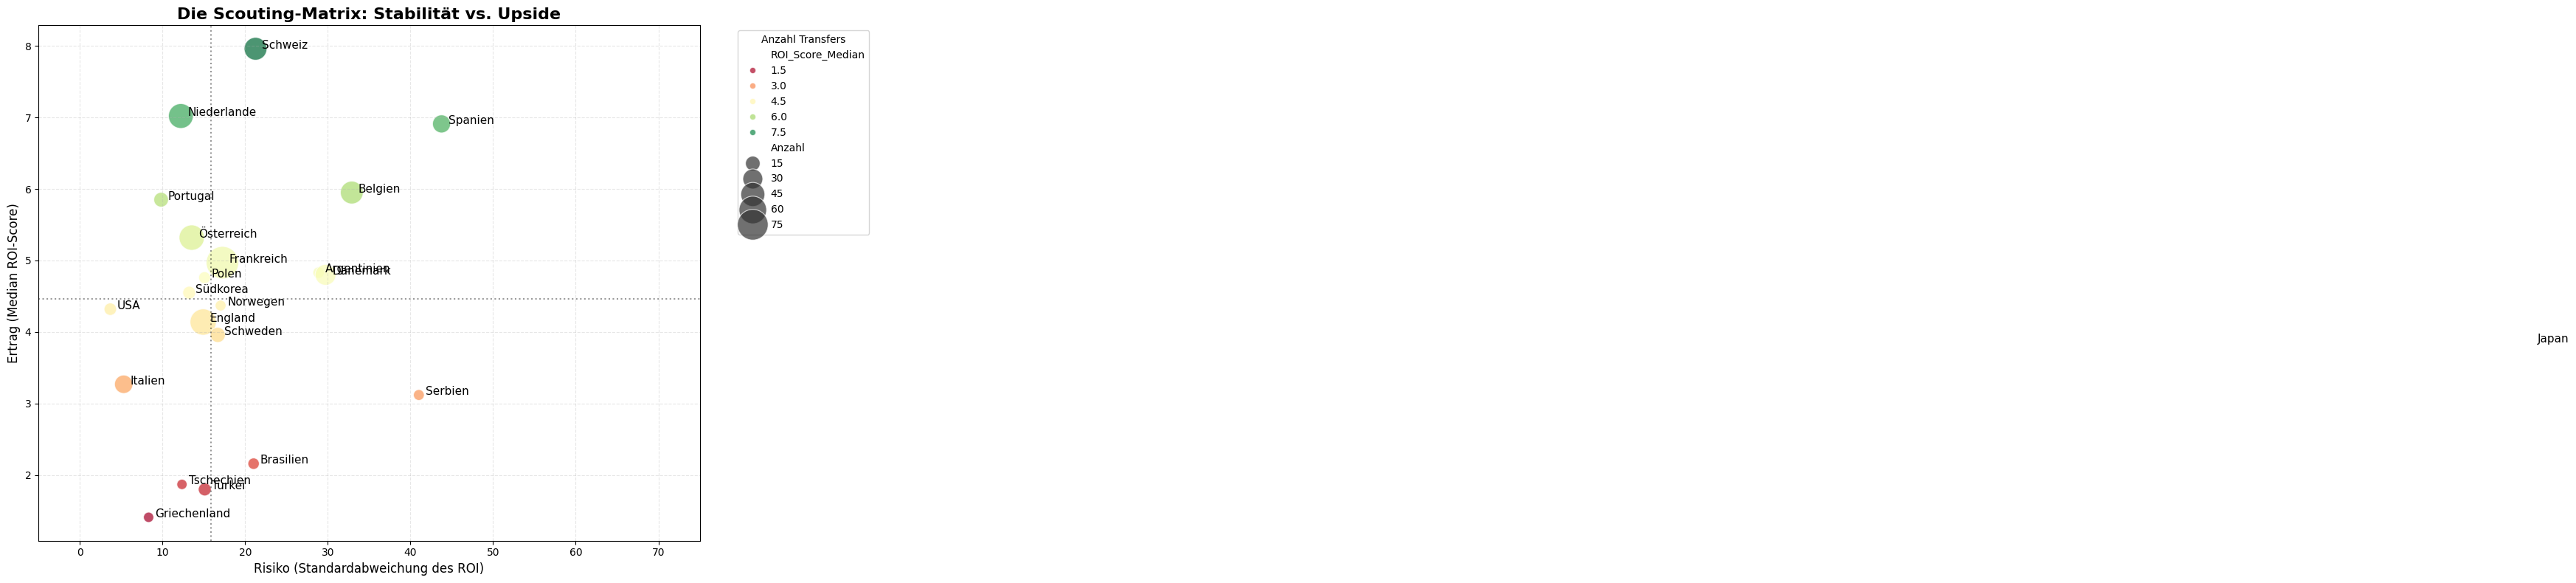

In [ ]:
# --- Grafik 2: Risk vs. Reward Matrix (Scatter-Plot) ---
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(data=plot_data, x='Risiko_std', y='ROI_Score_Median', 
                         size='Anzahl', sizes=(100, 1000), alpha=0.7, 
                         hue='ROI_Score_Median', palette='RdYlGn')

# Beschriftung der Punkte mit den Klarnamen
for i in range(plot_data.shape[0]):
    plt.text(plot_data.Risiko_std[i] + 0.8, plot_data.ROI_Score_Median[i], 
             plot_data.Land[i], fontsize=11, fontweight='medium')

plt.title('Die Scouting-Matrix: Stabilität vs. Upside', fontsize=16, fontweight='bold')
plt.xlabel('Risiko (Standardabweichung des ROI)', fontsize=12)
plt.ylabel('Ertrag (Median ROI-Score)', fontsize=12)

# Hilfslinien zur Orientierung (Mediane über alle Ligen)
plt.axhline(plot_data['ROI_Score_Median'].median(), color='black', linestyle=':', alpha=0.4)
plt.axvline(plot_data['Risiko_std'].median(), color='black', linestyle=':', alpha=0.4)

plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.legend(title='Anzahl Transfers', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.xlim(-5, 75)
plt.show()